--- PHYSICS ANALYSIS ---
Mode 1: Frequency = 6.325 rad/s
       Relative Motion [x1, x2] = [0.70710678 0.70710678]
Mode 2: Frequency = 6.928 rad/s
       Relative Motion [x1, x2] = [ 0.70710678 -0.70710678]


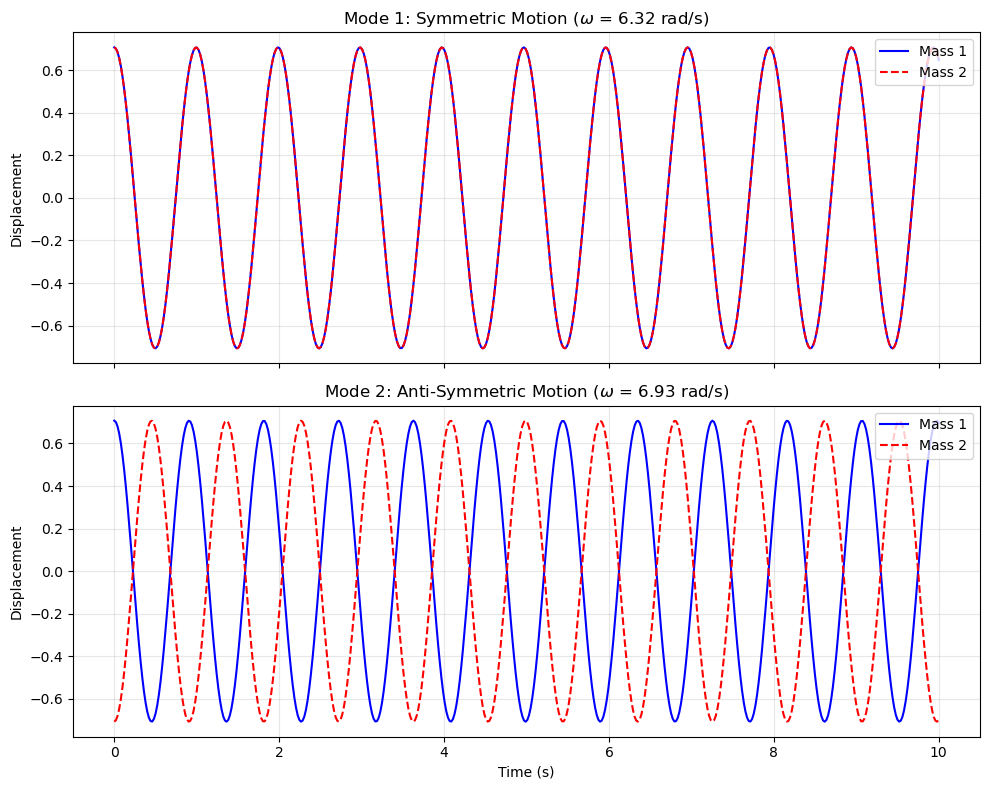

--- PHYSICAL INTERPRETATION ---
Mode 1 (Low Freq: 6.32 rad/s): Both lines move 'In Phase'.
Mode 2 (High Freq: 6.93 rad/s): Lines move 'Out of Phase' (mirrored).
 
 a). Looking at the two-mass system
 - If the masses are different, and k1=k3 is the same than for mode 1 the larger mass has the higher amplitude and kind of drags the smaller mass, while in mode 2 the smaller mass has a higher amplitude, but has a much weaker pull on mass 2
 - If k2 is very small with k1=k3 aand m1=m2, then the amplitudes of motion for each mass in both modes become equal, and the frequncy decreases from the previous cases
 - If you double all spring constants than the frequncy increases
 b). Extending to N masses
 - In the first 4 modes, there are 6 zero crossing nodes in total 1 in mode 2 and 2 in both mode 3, and 3 in mode 4, so it looks like there are n-1 zero crossing nodes in each mode (where in = the mode), so in mode 10 there should be 9 zero crossing nodes
 - In the 10 mass sytem at mode 10 there a

In [2]:
# 1. Physics of Vibration
# Code from linear algebra worksheet


import numpy as np
import matplotlib.pyplot as plt

"""
LINEAR ALGEBRA FOR PHYSICS
Find the frequencies and shapes of motion for two coupled masses.
System: Wall --[k1]-- (m1) --[k2]-- (m2) --[k3]-- Wall
"""

# --- 1. SET UP THE SYSTEM ---
m1, m2 = 1.0, 1.0       # Masses (kg)
k1, k2, k3 = 40, 4, 40 # Spring constants (N/m)

# --- 2. BUILD THE STIFFNESS MATRIX (K) ---
# For a 2-mass system, the matrix looks like:
# [ (k1+k2)/m1 ,   -k2/m1    ]
# [   -k2/m2   , (k2+k3)/m2  ]
K = np.array([
    [(k1 + k2)/m1, -k2/m1],
    [-k2/m2, (k2 + k3)/m2]
])

# --- 3. SOLVE THE EIGENVALUE PROBLEM ---
# evals: The eigenvalues (omega squared)
# evecs: The eigenvectors (The 'Shape' of the motion)
evals, evecs = np.linalg.eig(K) # K is a matrix

# --- SORTING ---
# np.linalg.eig returns modes in arbitrary order. 
# We sort them by frequency (eigenvalue) to ensure consistent labeling.
idx = np.argsort(evals)
evals = evals[idx]
evecs = evecs[:, idx]

# The natural frequencies (rad/s) are the square roots
omegas = np.sqrt(evals)

print("--- PHYSICS ANALYSIS ---")
for i in range(len(omegas)):
    print(f"Mode {i+1}: Frequency = {omegas[i]:.3f} rad/s")
    print(f"       Relative Motion [x1, x2] = {evecs[:, i]}")

# --- 4. CREATE TIME-SERIES DATA ---
t = np.linspace(0, 10, 500)
 
def get_mode_motion(t, omega, eigenvector):
    # x(t) = Amplitude * cos(omega * t)
    # The eigenvector [A, B] gives the relative amplitude of mass 1 and mass 2
    x1 = eigenvector[0] * np.cos(omega * t)
    x2 = eigenvector[1] * np.cos(omega * t)
    return x1, x2

# --- 5. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# MODE 1 (Symmetric / Lower Frequency)
x1_m1, x2_m1 = get_mode_motion(t, omegas[0], evecs[:, 0])
ax1.plot(t, x1_m1, 'b-', label='Mass 1')
ax1.plot(t, x2_m1, 'r--', label='Mass 2')
ax1.set_title(f"Mode 1: Symmetric Motion ($\omega$ = {omegas[0]:.2f} rad/s)")
ax1.set_ylabel("Displacement")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# MODE 2 (Anti-Symmetric / Higher Frequency)
x1_m2, x2_m2 = get_mode_motion(t, omegas[1], evecs[:, 1])
ax2.plot(t, x1_m2, 'b-', label='Mass 1')
ax2.plot(t, x2_m2, 'r--', label='Mass 2')
ax2.set_title(f"Mode 2: Anti-Symmetric Motion ($\omega$ = {omegas[1]:.2f} rad/s)")
ax2.set_ylabel("Displacement")
ax2.set_xlabel("Time (s)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("--- PHYSICAL INTERPRETATION ---")
print(f"Mode 1 (Low Freq: {omegas[0]:.2f} rad/s): Both lines move 'In Phase'.")
print(f"Mode 2 (High Freq: {omegas[1]:.2f} rad/s): Lines move 'Out of Phase' (mirrored).")
print(" ")

print(" a). Looking at the two-mass system")
print(" - If the masses are different, and k1=k3 is the same than for mode 1 the larger mass has the higher amplitude and kind of drags the smaller mass, while in mode 2 the smaller mass has a higher amplitude, but has a much weaker pull on mass 2")
print(" - If k2 is very small with k1=k3 aand m1=m2, then the amplitudes of motion for each mass in both modes become equal, and the frequncy decreases from the previous cases")
print(" - If you double all spring constants than the frequncy increases")
print(" b). Extending to N masses")
print(" - In the first 4 modes, there are 6 zero crossing nodes in total 1 in mode 2 and 2 in both mode 3, and 3 in mode 4, so it looks like there are n-1 zero crossing nodes in each mode (where in = the mode), so in mode 10 there should be 9 zero crossing nodes")
print(" - In the 10 mass sytem at mode 10 there ae 9 nodes and it appears as if every mass is bouncing off one another like there is a noe between every mass")








In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # Required for Jupyter rendering
import numpy as np
import matplotlib.pyplot as plt


"""
LONGITUDINAL NORMAL MODES VISUALIZER
Goal: Move away from 'transverse' looking graphs to see actual 
      back-and-forth motion of a coupled mass chain.
"""

# --- 1. PHYSICAL CONSTANTS ---
N = 10        # Number of masses
m = 1.0        # Mass (kg)
k = 100.0      # Spring constant (N/m)
spacing = 1.0  # Equilibrium distance

# --- 2. SOLVE THE LINEAR ALGEBRA ---
diag_val = 2 * k / m
off_diag = -k / m
A = np.diag(np.full(N, diag_val)) + \
    np.diag(np.full(N-1, off_diag), k=1) + \
    np.diag(np.full(N-1, off_diag), k=-1)

evals, evecs = np.linalg.eig(A)
idx = np.argsort(evals)
omegas = np.sqrt(evals[idx])
evecs = evecs[:, idx]

# --- 3. ANIMATION SETUP ---
selected_mode = 9  # Change this (0 to 9) to see different harmonics
amplitude = 0.4    

x_eq = np.arange(1, N + 1) * spacing
y_zeros = np.zeros(N)

fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, (N + 1) * spacing)
ax.set_ylim(-0.5, 0.5)

# Initialize visual elements
springs, = ax.plot(x_eq, y_zeros, color='gray', lw=1, alpha=0.4, zorder=1)
mass_dots, = ax.plot(x_eq, y_zeros, 'bo', markersize=12, label="Masses", zorder=2)
ax.scatter(x_eq, y_zeros, marker='|', color='red', alpha=0.3, label="Equilibrium")

ax.set_title(f"Longitudinal Mode {selected_mode + 1} ($\omega$ = {omegas[selected_mode]:.2f} rad/s)")
ax.set_xlabel("Physical Position (x)")
ax.get_yaxis().set_visible(False)
ax.legend(loc='upper right')

def update(frame):
    # frame/10.0 provides the time variable 't'
    t = frame * 0.1
    displacements = amplitude * evecs[:, selected_mode] * np.cos(omegas[selected_mode] * t)
    current_x = x_eq + displacements
    
    mass_dots.set_data(current_x, y_zeros)
    springs.set_data(current_x, y_zeros)
    return (mass_dots, springs)

# --- 4. JUPYTER RENDERING ---
# We create the animation object as before
ani = FuncAnimation(fig, update, frames=100, interval=50, blit=True)

# CRITICAL FOR JUPYTER: 
# Instead of plt.show(), we close the plot and display it as JSHTML.
plt.close() 
HTML(ani.to_jshtml())

print(" c). Working with the array")
print("print(evecs.shape),") 
print(evecs.shape)
print(evecs[0])
print(" - The evec[0] gives the first mode")
print(" -  X= AV, (Amplitude = A =0.4)  X = 0.4(V) where V is mode 5")
X = 0.4 * evecs[4][2]
print(" - The displacement of the 3rd mass in mode 5 is: ", X)

 c). Working with the array
print(evecs.shape),
(10, 10)
[-0.12013117  0.23053002 -0.3222527  -0.38786839  0.42206128 -0.42206128
  0.38786839  0.3222527   0.23053002  0.12013117]
 - The evec[0] gives the first mode
 -  X= AV, (Amplitude = A =0.4)  X = 0.4(V) where V is mode 5
 - The displacement of the 3rd mass in mode 5 is:  0.15514735442365324


In [4]:
# 2.  Static Systems: Solving for the Unknown
import numpy as np
import matplotlib.pyplot as plt


# kirchoffs problem
k = np.array([[10, -2, 0], [-2, 8, -4],[ 0, -4, 6]])
x = np.array([12, 0, -5])


solution = np.linalg.solve(k, x)
i_1 = solution[0]
i_2 = solution[1]
i_3 = solution[2]
print(" a). The currents I1, I2, I3, respectively are: ", round(i_1,3), " ", round(i_2,3), " ", round(i_3,3))


theta = 30
theta_2 = 45
W=1
T_net = np.array([
    [-1*np.cos(theta), np.cos(theta_2)],
    [np.sin(theta), np.sin(theta_2)]
])
f = np.array([0, W])
solution_2 = np.linalg.solve(T_net,f)
T_1 = solution[0]
T_2 = solution[1]
print(" b). The Tension T_1 and T_2 respectively are (if w = 1): ", round(T_1,3), " ", round(T_2,3))


 a). The currents I1, I2, I3, respectively are:  1.162   -0.189   -0.959
 b). The Tension T_1 and T_2 respectively are (if w = 1):  1.162   -0.189


Force:


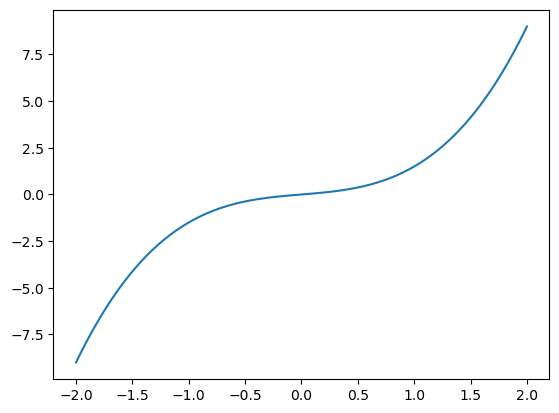

In [5]:
# 3. SymPy: Duffing Oscillator

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# This command makes the output look like LaTeX math
sp.init_printing()


x, alpha, beta = sp.symbols('x alpha beta')

V_x = 0.5*(alpha)*x**2 + 0.25*(beta)*x**4
force = sp.diff(V_x, x)
print("Force:")

display(force)
force = force.subs({alpha: 0.5, beta: 1.0})
force_plot = sp.lambdify(x, force, 'numpy')

#print(y_vals)
x_vals = np.linspace(-2, 2, 100)
y_vals = force_plot(x_vals)
plt.plot(x_vals, y_vals, label="force plot")

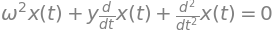

The General Solution:


The overdamped:


In [6]:
# 4. SymPy: Solving the Damped Oscillator (ODEs)

# This command makes the output look like LaTeX math
sp.init_printing()
t, y, omega = sp.symbols('t y omega')

x = sp.Function('x')
diffeq = sp.Eq(x(t).diff(t, t) + y*x(t).diff(t) + x(t) * omega**2, 0)
display(diffeq)

print("The General Solution:")
sol = sp.dsolve(diffeq, x(t))
display(sol)

print("The overdamped:")
diffeq = diffeq.subs({y: 5, omega: 2})
sol = sp.dsolve(diffeq, x(t))
display(sol)




This is the energy ground state:  92.80827002962013


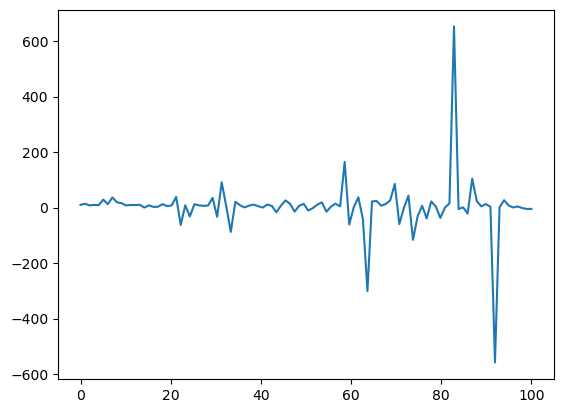

In [41]:
# 5. Quantum: The Finite Square Well
h = 6.626e-34
h_bar = h/(2*np.pi) # defining the h_bar constnt
E, L, m, V_0 = sp.symbols('E L m V_0') # creating variables


F_E = sp.sqrt(V_0 - E) - sp.sqrt(E)*sp.tan(sp.sqrt(2*m*(L**2)*E)/h_bar) # RHS- LHS
F_E = F_E.subs({L: 0.01, m: 1.6e-27, V_0: 100}) # Assigning values to all the variables accept E [V_0 has to be greater or = to E]
F_E_plot = sp.lambdify(E, F_E, 'numpy')  # using lambdify to plot
E_vals = np.linspace(0, 100, 100) #E is 0-100 and is NOT greater than V_0
F_E_vals = F_E_plot(E_vals)
plt.plot(E_vals, F_E_vals, label="force plot")

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

result = root_scalar(F_E_plot, bracket= [0,100], method = 'bisect') #F_e plot as the function to bisect, from 0-100

Energy_ground = result.root # finds the zero

print("This is the energy ground state: ", Energy_ground)

hello world
